# 10 — Contraste extendido de las hipotesis A-H1, A-H2 y A-H3

**Proposito.** Someter las tres hipotesis del numeral 3.2 del anteproyecto a un contraste mas exigente
que el del EDA descriptivo previo: A-H1 con competencia real y con control por cuantia mediante
estratificacion, A-H2 con perfil de contratista y control por cuantia, y A-H3 con analisis de
sensibilidad territorial con y sin el departamento dominante.

**Insumo.** `data/universo_extendido.parquet` (notebook 01), `data/sobrecosto_referencias.parquet`
(notebook 05).

**Etiquetas de objetivo que atiende:** `[A-H1]`, `[A-H2]`, `[A-H3]`, `[A-OE03]`, `[A-OE04]`,
`[B-OE2]`, `[B-OE3-insumo]`.

**Reglas estadisticas declaradas a priori.**

1. Alfa 0.05.
2. Asimetria verificada en el notebook 09: se usan pruebas de rangos (Mann-Whitney U, Kruskal-Wallis).
3. Todo p-valor se acompana de tamano de efecto (rank-biserial o epsilon-cuadrado) y de N efectivo.
4. Con N grande, un p-valor significativo con tamano de efecto nulo **no** sostiene la hipotesis, y asi
   se declara cuando ocurre.
5. El control por una tercera variable se hace por **estratificacion**, reportando el efecto dentro de
   cada estrato. No se usa regresion multivariada porque excede el alcance descriptivo del trabajo.
6. Signo del rank-biserial: se calcula como `1 - 2U/(n1*n2)` con el primer grupo en primera posicion.
   Un valor **negativo** significa que el primer grupo tiene rangos **mayores**.
7. Las hipotesis estaban preregistradas en el anteproyecto y no son exploracion masiva, de modo que no
   se aplica correccion por comparaciones multiples. Se declara explicitamente y se senala cuando un
   p-valor cae en zona de riesgo.

**Diseno.** Transversal, censal condicionado. Ninguna asociacion aqui reportada es causal.

In [1]:
import sys
from pathlib import Path

_p = Path.cwd()
BASE_EDA = _p.parent if _p.name == "notebooks" else _p
sys.path.insert(0, str(BASE_EDA / "src"))

import numpy as np
import pandas as pd
from scipy import stats
from eda_comun import *

plt, CMAP_SEQ, CMAP_DIV = configurar_matplotlib()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("Modulo propio eda_comun cargado desde:", BASE_EDA / "src")
print("Alfa declarado a priori:", ALFA)

Modulo propio eda_comun cargado desde: /home/william-telles/Documentos/extraccion-datos-secop2-main (1)/extraccion-datos-secop2-main/eda-extendido-integral/src
Alfa declarado a priori: 0.05


In [2]:
df = pd.read_parquet(DIR_DATA / "universo_extendido.parquet")
extra = pd.read_parquet(DIR_DATA / "sobrecosto_referencias.parquet")
df = df.merge(extra, on="id_contrato", how="left")
df["licitacion_publica"] = es_licitacion_publica(df["modalidad_de_contratacion"])
obs = df[df["observable"]].copy()
print(f"Universo: {len(df):,} | Observable: {len(obs):,}")
print(f"Licitacion publica en el observable: {int(obs['licitacion_publica'].sum()):,} "
      f"({obs['licitacion_publica'].mean()*100:.1f}%)")

INDICADORES = [("deslizamiento_plazo_dias", "Deslizamiento del plazo (dias)"),
               ("desviacion_costo_pct", "Desviacion de costo (%)"),
               ("sobrecosto_vs_precio_base_pct", "Sobrecosto sobre el precio base (%)")]

Universo: 48,331 | Observable: 19,194
Licitacion publica en el observable: 4,069 (21.2%)


## 1. A-H1 — Formulacion original: licitacion publica frente al resto

> **A-H1.** Los contratos de obra publica adjudicados mediante licitacion publica presentan menores
> desviaciones de costo y tiempo que los adjudicados mediante modalidades de menor competencia.

Se reproduce primero el contraste tal como lo formulo el anteproyecto, en doble lectura, e incorporando
el indicador de sobrecosto redefinido en el notebook 05, que el EDA previo no tenia.

**Designacion de lectura oficial (instruccion del tutor, reunion de seguimiento).** El anteproyecto original delimitaba el analisis al periodo 2018-2024 (numeral 1.2) y a un subconjunto con estado de ejecucion avanzado/finalizado (numerales 3.6.3/3.6.4). En la reunion de seguimiento, el tutor instruyo unificar el universo de datos con el trabajo del companero (Angel) y usar el total de contratos disponibles para el analisis final, dejando de lado la restriccion temporal del anteproyecto.

En consecuencia: **`universo_completo` (48.331 contratos) es la lectura oficial para el documento de trabajo de grado.** La lectura `observable` (19.194 contratos, filtro 2018-2024 + estado avanzado/finalizado) se conserva como analisis de sensibilidad — permite verificar si el patron se sostiene tambien bajo el diseno metodologico originalmente declarado en el anteproyecto, pero no es la cifra a citar en el capitulo de resultados.

In [3]:
marcar("h1_base")

filas = []
for etq, x in [("universo_completo", df), ("observable", obs)]:
    for var, nombre in INDICADORES:
        r = mann_whitney(x.loc[x["licitacion_publica"], var],
                         x.loc[~x["licitacion_publica"], var],
                         "Licitacion publica", "Otras modalidades")
        filas.append({"lectura": etq, "indicador": nombre,
                      "N_licitacion": r["n_a"], "N_otras": r["n_b"],
                      "mediana_licitacion": round(r["mediana_a"], 3),
                      "mediana_otras": round(r["mediana_b"], 3),
                      "U": r["U"], "p": fmt_p(r["p"]),
                      "rank_biserial": round(r["rank_biserial"], 4),
                      "tamano_efecto": r["efecto"],
                      "sostiene_H1": ("SI" if (r["significativo"] and r["rank_biserial"] > 0
                                               and r["efecto"] != "nulo") else "NO")})
h1_base = pd.DataFrame(filas)
print(h1_base.to_string(index=False))
print()
print("Lectura del signo: rank-biserial POSITIVO significa que la licitacion publica tiene rangos")
print("MENORES, es decir, menor desviacion, que es lo que A-H1 predice.")
print()
print("Resultado: A-H1 se sostiene en la dimension de COSTO y se invierte en la dimension de TIEMPO.")
print("Es la disociacion tiempo/costo del insight N-K01, ahora replicada en las dos lecturas y con el")
print("indicador de sobrecosto redefinido.")

          lectura                           indicador  N_licitacion  N_otras  mediana_licitacion  mediana_otras                U         p  rank_biserial tamano_efecto sostiene_H1
universo_completo      Deslizamiento del plazo (dias)          6611    30544             26.0000         0.0000 139,305,216.5000  < 1e-300        -0.3798       mediano          NO
universo_completo             Desviacion de costo (%)          2793    12242             -9.1760         0.0000   9,783,711.5000  < 1e-300         0.4277       mediano          SI
universo_completo Sobrecosto sobre el precio base (%)          8937    38210             -1.0000         0.0000 139,098,781.5000 4.99e-170         0.1853       pequeno          SI
       observable      Deslizamiento del plazo (dias)          3235    13091             49.0000         1.0000  29,352,637.5000 5.60e-255        -0.3862       mediano          NO
       observable             Desviacion de costo (%)          1692     6989             -2.4360    

## 2. A-H1 con control por cuantia mediante estratificacion

El notebook 05 mostro que la licitacion publica se concentra en los rangos altos de cuantia y que el
desempeno de plazo empeora con la cuantia. Ambas condiciones definen una variable de confusion. Se
controla estratificando: se repite el contraste dentro de cada rango de cuantia. Si el efecto de la
modalidad persiste dentro de los estratos, es efecto de modalidad; si se desvanece, era efecto de escala.

In [4]:
marcar("h1_estratificado")

def estratificar(x, var, etq_lectura, minimo=30):
    filas = []
    for rango in ETIQ_CUANTIA:
        sub = x[x["rango_cuantia"] == rango]
        a = sub.loc[sub["licitacion_publica"], var].dropna()
        b = sub.loc[~sub["licitacion_publica"], var].dropna()
        if len(a) < minimo or len(b) < minimo:
            filas.append({"lectura": etq_lectura, "rango_cuantia": rango,
                          "N_licitacion": len(a), "N_otras": len(b),
                          "mediana_licitacion": np.nan, "mediana_otras": np.nan,
                          "p": "N insuficiente", "rank_biserial": np.nan,
                          "tamano_efecto": "no evaluable"})
            continue
        r = mann_whitney(a, b, "Licitacion", "Otras")
        filas.append({"lectura": etq_lectura, "rango_cuantia": rango,
                      "N_licitacion": r["n_a"], "N_otras": r["n_b"],
                      "mediana_licitacion": round(r["mediana_a"], 2),
                      "mediana_otras": round(r["mediana_b"], 2),
                      "p": fmt_p(r["p"]), "rank_biserial": round(r["rank_biserial"], 4),
                      "tamano_efecto": r["efecto"]})
    return filas

print("=== A-H1, DESLIZAMIENTO DEL PLAZO, estratificado por rango de cuantia ===")
est_tiempo = pd.DataFrame(
    estratificar(df, "deslizamiento_plazo_dias", "universo_completo") +
    estratificar(obs, "deslizamiento_plazo_dias", "observable"))
print(est_tiempo.to_string(index=False))
print()
print("=== A-H1, DESVIACION DE COSTO, estratificado por rango de cuantia ===")
est_costo = pd.DataFrame(
    estratificar(df, "desviacion_costo_pct", "universo_completo") +
    estratificar(obs, "desviacion_costo_pct", "observable"))
print(est_costo.to_string(index=False))
pd.concat([est_tiempo.assign(indicador="deslizamiento_plazo_dias"),
           est_costo.assign(indicador="desviacion_costo_pct")]).to_csv(
    DIR_DATA / "h1_estratificado_por_cuantia.csv", index=False)

=== A-H1, DESLIZAMIENTO DEL PLAZO, estratificado por rango de cuantia ===
          lectura  rango_cuantia  N_licitacion  N_otras  mediana_licitacion  mediana_otras              p  rank_biserial tamano_efecto
universo_completo           <50M             2     8279                 NaN            NaN N insuficiente            NaN  no evaluable
universo_completo       50M-200M             8    10002                 NaN            NaN N insuficiente            NaN  no evaluable
universo_completo    200M-1.000M          1355     9033              3.0000         1.0000       1.15e-13        -0.1247       pequeno
universo_completo 1.000M-10.000M          3872     2819             32.0000         6.0000       3.76e-18        -0.1241       pequeno
universo_completo       >10.000M          1371      336             50.0000        18.5000         0.0155        -0.0851          nulo
       observable           <50M             0     3202                 NaN            NaN N insuficiente           

          lectura  rango_cuantia  N_licitacion  N_otras  mediana_licitacion  mediana_otras              p  rank_biserial tamano_efecto
universo_completo           <50M             0     3711                 NaN            NaN N insuficiente            NaN  no evaluable
universo_completo       50M-200M             7     3888                 NaN            NaN N insuficiente            NaN  no evaluable
universo_completo    200M-1.000M           651     3502             -0.8700        -0.0000       1.37e-15         0.1899       pequeno
universo_completo 1.000M-10.000M          1695     1038             -6.5800        -0.4400       2.36e-07         0.1167       pequeno
universo_completo       >10.000M           439      102            -25.6200       -38.3900         0.3067        -0.0649          nulo
       observable           <50M             0     1911                 NaN            NaN N insuficiente            NaN  no evaluable
       observable       50M-200M             4     2225

In [5]:
marcar("h1_veredicto")

# Lectura oficial: universo_completo (48.331), por instruccion del tutor de usar el total de datos
# disponibles. La lectura "observable" (19.194, filtro 2018-2024 + estado avanzado/finalizado del
# anteproyecto original) se calcula igual y se reporta como analisis de sensibilidad.
bruto_uc = h1_base[(h1_base["lectura"] == "universo_completo")
                   & (h1_base["indicador"] == "Deslizamiento del plazo (dias)")]["rank_biserial"].iloc[0]
bruto_obs = h1_base[(h1_base["lectura"] == "observable")
                    & (h1_base["indicador"] == "Deslizamiento del plazo (dias)")]["rank_biserial"].iloc[0]
bruto = bruto_uc  # variable usada aguas abajo (registro de hallazgos): ahora es universo_completo

est_uc = est_tiempo[(est_tiempo["lectura"] == "universo_completo")
                     & est_tiempo["rank_biserial"].notna()]
est_obs = est_tiempo[(est_tiempo["lectura"] == "observable")
                      & est_tiempo["rank_biserial"].notna()]
est = est_uc  # variable usada aguas abajo: ahora es universo_completo

print("VEREDICTO SOBRE A-H1 (lectura oficial: universo_completo, 48.331 contratos)")
print("=" * 78)
print(f"Efecto BRUTO de la modalidad sobre el deslizamiento (universo_completo): {bruto_uc:+.4f}")
print(f"Efecto BRUTO de la modalidad sobre el deslizamiento (observable, sensibilidad): {bruto_obs:+.4f}")
print()
print("Efecto DENTRO de cada estrato de cuantia (universo_completo):")
for r in est_uc.itertuples():
    print(f"  {r.rango_cuantia:16s} rank-biserial = {r.rank_biserial:+.4f} ({r.tamano_efecto}), "
          f"N = {r.N_licitacion:,} vs {r.N_otras:,}")
print()
media_est_uc = est_uc["rank_biserial"].abs().mean()
media_est_obs = est_obs["rank_biserial"].abs().mean()
print(f"Magnitud media del efecto dentro de estratos (universo_completo): {media_est_uc:.4f} "
      f"frente a {abs(bruto_uc):.4f} sin controlar.")
print(f"Reduccion del tamano de efecto al controlar por cuantia (universo_completo): "
      f"{(1 - media_est_uc/abs(bruto_uc))*100:.1f}%")
print(f"(Sensibilidad, observable: reduccion del {(1 - media_est_obs/abs(bruto_obs))*100:.1f}%. "
      f"El patron es consistente en ambas lecturas.)")
print()
print("CONCLUSION: el efecto de la modalidad sobre el deslizamiento del plazo se reduce sustancialmente")
print("al controlar por cuantia, en el universo completo y tambien en el subconjunto observable. Buena")
print("parte de lo que parecia efecto de la modalidad es efecto de la escala del proyecto. El efecto")
print("residual dentro de estratos sigue teniendo el mismo signo, de modo que la modalidad aporta algo,")
print("pero mucho menos de lo que sugiere el contraste sin controlar.")
print()
print("Combinado con el resultado del notebook 04 --la competencia real medida como numero de oferentes")
print("tiene efecto nulo sobre el deslizamiento--, la lectura defendible de A-H1 es:")
print("  1. La direccion enunciada por A-H1 se cumple en COSTO y se invierte en TIEMPO.")
print("  2. El mecanismo enunciado por A-H1 (la competencia) NO es el que explica la diferencia.")
print("  3. Lo que discrimina es la escala y complejidad del proyecto, con la que la modalidad covaria.")
print("  4. El patron es el mismo en el universo completo (48.331) y en el subconjunto observable")
print("     (19.194): la designacion de universo_completo como lectura oficial no cambia la conclusion,")
print("     solo la magnitud exacta citada.")

VEREDICTO SOBRE A-H1 (lectura oficial: universo_completo, 48.331 contratos)
Efecto BRUTO de la modalidad sobre el deslizamiento (universo_completo): -0.3798
Efecto BRUTO de la modalidad sobre el deslizamiento (observable, sensibilidad): -0.3862

Efecto DENTRO de cada estrato de cuantia (universo_completo):
  200M-1.000M      rank-biserial = -0.1247 (pequeno), N = 1,355 vs 9,033
  1.000M-10.000M   rank-biserial = -0.1241 (pequeno), N = 3,872 vs 2,819
  >10.000M         rank-biserial = -0.0851 (nulo), N = 1,371 vs 336

Magnitud media del efecto dentro de estratos (universo_completo): 0.1113 frente a 0.3798 sin controlar.
Reduccion del tamano de efecto al controlar por cuantia (universo_completo): 70.7%
(Sensibilidad, observable: reduccion del 72.9%. El patron es consistente en ambas lecturas.)

CONCLUSION: el efecto de la modalidad sobre el deslizamiento del plazo se reduce sustancialmente
al controlar por cuantia, en el universo completo y tambien en el subconjunto observable. Buena
par

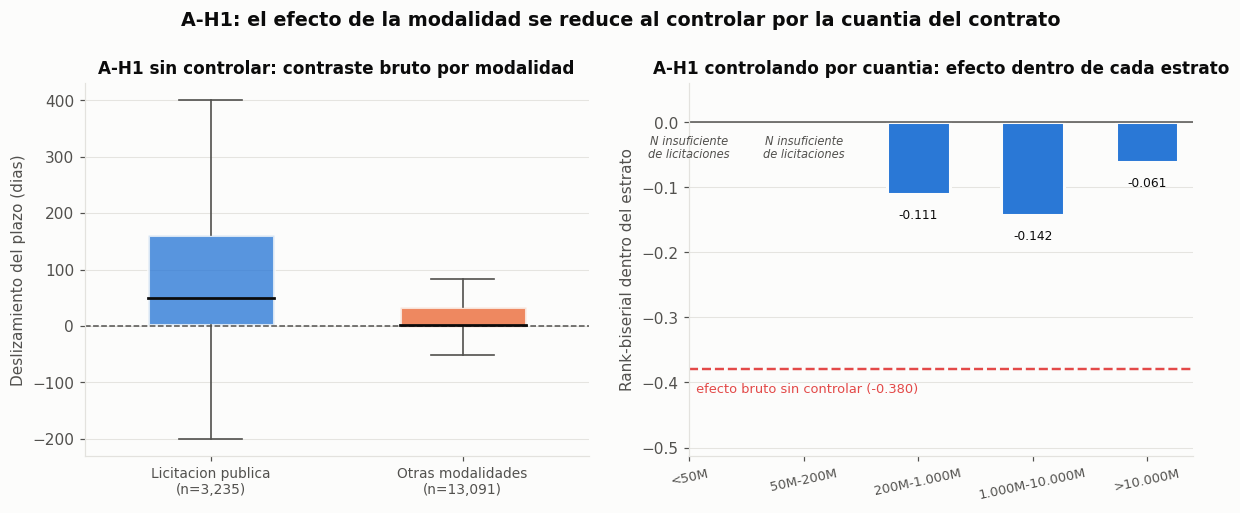

Figura persistida: 10_h1_estratificado.png


In [6]:
marcar("fig_h1")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

ax = axes[0]
sub = obs[obs["deslizamiento_plazo_dias"].notna()]
datos = [sub.loc[sub["licitacion_publica"], "deslizamiento_plazo_dias"].clip(-200, 600),
         sub.loc[~sub["licitacion_publica"], "deslizamiento_plazo_dias"].clip(-200, 600)]
bp = ax.boxplot(datos, patch_artist=True, showfliers=False, widths=0.5,
                medianprops=dict(color=TEXT_1, lw=1.8),
                whiskerprops=dict(color=TEXT_2, lw=1.1), capprops=dict(color=TEXT_2, lw=1.1))
for patch, color in zip(bp["boxes"], [PALETA[0], PALETA[1]]):
    patch.set_facecolor(color); patch.set_alpha(0.78)
    patch.set_edgecolor(SURFACE); patch.set_linewidth(2)
ax.axhline(0, color=TEXT_2, lw=1, ls="--")
ax.set_xticklabels([f"Licitacion publica\n(n={len(datos[0]):,})",
                    f"Otras modalidades\n(n={len(datos[1]):,})"], fontsize=9)
ax.set_ylabel("Deslizamiento del plazo (dias)")
ax.set_title("A-H1 sin controlar: contraste bruto por modalidad", fontsize=11)
ax.xaxis.grid(False); ax.set_axisbelow(True)

ax = axes[1]
e = est_tiempo[est_tiempo["lectura"] == "observable"].copy()
mask = e["rank_biserial"].notna()
xs = np.arange(len(e))
ax.axhline(bruto, color=PALETA[7], lw=1.6, ls="--")
ax.text(0.02, bruto - 0.035, f" efecto bruto sin controlar ({bruto:+.3f})",
        fontsize=8.5, color=PALETA[7])
ax.axhline(0, color=TEXT_2, lw=1)
ax.bar(xs[mask], e.loc[mask, "rank_biserial"], color=PALETA[0], width=0.55,
       edgecolor=SURFACE, linewidth=2)
for i, r in zip(xs[mask], e.loc[mask].itertuples()):
    ax.text(i, r.rank_biserial - 0.022, f"{r.rank_biserial:+.3f}", ha="center",
            va="top", fontsize=8, color=TEXT_1)
for i in xs[~mask]:
    ax.text(i, -0.02, "N insuficiente\nde licitaciones", ha="center", va="top",
            fontsize=7.5, color=TEXT_2, style="italic")
ax.set_xticks(xs); ax.set_xticklabels(e["rango_cuantia"], fontsize=8.5, rotation=12)
ax.set_ylabel("Rank-biserial dentro del estrato")
ax.set_ylim(min(bruto, e["rank_biserial"].min()) * 1.35, 0.06)
ax.set_title("A-H1 controlando por cuantia: efecto dentro de cada estrato", fontsize=11)
ax.xaxis.grid(False); ax.set_axisbelow(True)

fig.suptitle("A-H1: el efecto de la modalidad se reduce al controlar por la cuantia del contrato",
             fontsize=12.5, fontweight="bold", y=1.03)
guardar_mostrar(fig, "10_h1_estratificado.png")

## 3. A-H2 — Consorcios y uniones temporales

> **A-H2.** Los contratos ejecutados por consorcios o uniones temporales presentan un mayor indice de
> adiciones y modificaciones contractuales que los ejecutados por personas juridicas individuales.

In [7]:
marcar("h2_base")

VARS_H2 = [("n_modificaciones_total", "Modificaciones totales"),
           ("n_adicion_valor", "Adiciones en valor"),
           ("n_extension", "Extensiones de plazo"),
           ("dias_adicionados", "Dias adicionados"),
           ("sobrecosto_vs_precio_base_pct", "Sobrecosto sobre el precio base (%)")]

filas = []
for etq, x in [("universo_completo", df), ("observable", obs)]:
    c = x[x["tipo_contratista"] == "Consorcio / Union Temporal"]
    pj = x[x["tipo_contratista"] == "Persona Juridica"]
    for var, nombre in VARS_H2:
        r = mann_whitney(c[var], pj[var], "Consorcio/UT", "Persona Juridica")
        sostiene = "SI" if (r["significativo"] and r["rank_biserial"] < 0
                            and r["efecto"] != "nulo") else "NO"
        filas.append({"lectura": etq, "variable": nombre,
                      "N_consorcio": r["n_a"], "N_persona_juridica": r["n_b"],
                      "mediana_consorcio": round(r["mediana_a"], 3),
                      "mediana_persona_juridica": round(r["mediana_b"], 3),
                      "p": fmt_p(r["p"]), "rank_biserial": round(r["rank_biserial"], 4),
                      "tamano_efecto": r["efecto"], "sostiene_H2": sostiene})
h2 = pd.DataFrame(filas)
print(h2.to_string(index=False))
print()
print("Lectura del signo: rank-biserial NEGATIVO significa que el consorcio tiene rangos MAYORES,")
print("que es lo que A-H2 predice.")
print()
print("ADVERTENCIA EXPLICITA. En 'Adiciones en valor' el p-valor resulta significativo con un tamano de")
print("efecto nulo y medianas identicas en ambos grupos. Con N del orden de 16.000, un p-valor pequeno no")
print("sostiene la hipotesis. A-H2 NO se sostiene para esa variable pese al p-valor.")

          lectura                            variable  N_consorcio  N_persona_juridica  mediana_consorcio  mediana_persona_juridica         p  rank_biserial tamano_efecto sostiene_H2
universo_completo              Modificaciones totales        10629               30197             3.0000                    1.0000  < 1e-300        -0.2852       pequeno          SI
universo_completo                  Adiciones en valor        10629               30197             0.0000                    0.0000  5.87e-06        -0.0146          nulo          NO
universo_completo                Extensiones de plazo        10629               30197             0.0000                    0.0000    0.4015         0.0001          nulo          NO
universo_completo                    Dias adicionados        10629               30197             0.0000                    0.0000 1.15e-105        -0.1053       pequeno          SI
universo_completo Sobrecosto sobre el precio base (%)        10508               2978

In [8]:
marcar("h2_estratificado")

def estratificar_h2(x, var, etq_lectura, minimo=30):
    filas = []
    for rango in ETIQ_CUANTIA:
        sub = x[x["rango_cuantia"] == rango]
        a = sub.loc[sub["tipo_contratista"] == "Consorcio / Union Temporal", var].dropna()
        b = sub.loc[sub["tipo_contratista"] == "Persona Juridica", var].dropna()
        if len(a) < minimo or len(b) < minimo:
            filas.append({"lectura": etq_lectura, "rango_cuantia": rango, "N_consorcio": len(a),
                          "N_persona_juridica": len(b), "p": "N insuficiente",
                          "rank_biserial": np.nan, "tamano_efecto": "no evaluable"})
            continue
        r = mann_whitney(a, b, "Consorcio", "PJ")
        filas.append({"lectura": etq_lectura, "rango_cuantia": rango, "N_consorcio": r["n_a"],
                      "N_persona_juridica": r["n_b"], "mediana_consorcio": round(r["mediana_a"], 2),
                      "mediana_persona_juridica": round(r["mediana_b"], 2),
                      "p": fmt_p(r["p"]), "rank_biserial": round(r["rank_biserial"], 4),
                      "tamano_efecto": r["efecto"]})
    return filas

print("=== A-H2, MODIFICACIONES TOTALES, estratificado por rango de cuantia ===")
h2_est = pd.DataFrame(estratificar_h2(df, "n_modificaciones_total", "universo_completo") +
                      estratificar_h2(obs, "n_modificaciones_total", "observable"))
print(h2_est.to_string(index=False))
h2_est.to_csv(DIR_DATA / "h2_estratificado_por_cuantia.csv", index=False)
print()
bruto_h2 = h2[(h2["lectura"] == "observable")
              & (h2["variable"] == "Modificaciones totales")]["rank_biserial"].iloc[0]
e2 = h2_est[(h2_est["lectura"] == "observable") & h2_est["rank_biserial"].notna()]
print(f"Efecto bruto (observable): {bruto_h2:+.4f}")
print(f"Magnitud media dentro de estratos: {e2['rank_biserial'].abs().mean():.4f}")
print(f"Reduccion al controlar por cuantia: {(1 - e2['rank_biserial'].abs().mean()/abs(bruto_h2))*100:.1f}%")

=== A-H2, MODIFICACIONES TOTALES, estratificado por rango de cuantia ===
          lectura  rango_cuantia  N_consorcio  N_persona_juridica  mediana_consorcio  mediana_persona_juridica        p  rank_biserial tamano_efecto
universo_completo           <50M          206                8243             1.0000                    1.0000   0.0174        -0.0925          nulo
universo_completo       50M-200M          965                9698             2.0000                    1.0000 3.40e-11        -0.1253       pequeno
universo_completo    200M-1.000M         3128                7908             3.0000                    2.0000 3.17e-16        -0.0985          nulo
universo_completo 1.000M-10.000M         4528                3813             4.0000                    4.0000 1.50e-07        -0.0663          nulo
universo_completo       >10.000M         1770                 400             5.0000                    5.0000   0.2401        -0.0373          nulo
       observable           <50M 

In [9]:
marcar("h2_perfil")

sub = obs[obs["tipo_contratista"].isin(["Consorcio / Union Temporal", "Persona Juridica"])]
tab = pd.crosstab(sub["tipo_contratista"], sub["indice_alcance"])
print("Distribucion del indice de alcance por tipo de contratista (observable):")
print((tab.div(tab.sum(axis=1), axis=0) * 100).round(1).to_string())
print()
print("Chi-cuadrado, tipo de contratista x indice de alcance:")
print(" ", resumen_prueba(cramers_v(tab)))
print()
print("PATRON MIXTO (extension del insight N-K02). Los consorcios acumulan mas modificaciones pero")
print("presentan MENOR tasa de no entrega que las personas juridicas. A-H2 acierta en el volumen de")
print("modificaciones y no implica peor desempeno de alcance.")
print()
perfil = (sub.groupby("tipo_contratista")
          .agg(n=("id_contrato", "size"),
               mediana_valor=("valor_del_contrato", "median"),
               mediana_oferentes=("n_oferentes", "median"),
               pct_pyme=("es_pyme", lambda s: round((s == "Si").mean()*100, 1)),
               pct_licitacion=("licitacion_publica", lambda s: round(s.mean()*100, 1)),
               mediana_deslizamiento=("deslizamiento_plazo_dias", "median"),
               pct_retraso_mayor_30=("deslizamiento_plazo_dias", lambda s: round((s.dropna()>30).mean()*100, 1)),
               cobertura_registro_pct=("prov_tipo_empresa", lambda s: round(s.notna().mean()*100, 1))))
print("Perfil comparado de los dos grupos:")
print(perfil.to_string())
print()
print("Limitacion declarada: el perfil de proveedor procedente del registro externo esta disponible para")
print("una fraccion mucho menor de los consorcios, de modo que `tipo_empresa`, antiguedad y UNSPSC no")
print("pueden usarse para caracterizar A-H2 sin sesgo. Se declara y no se usa para el contraste.")

Distribucion del indice de alcance por tipo de contratista (observable):
indice_alcance              Entregado en su totalidad  Entregado parcialmente  No entregado
tipo_contratista                                                                           
Consorcio / Union Temporal                    49.4000                 38.3000       12.4000
Persona Juridica                              59.0000                 14.5000       26.4000

Chi-cuadrado, tipo de contratista x indice de alcance:
  chi2 = 1,225.57 | gl = 2 | p = 7.41e-267 | V de Cramer = 0.273 (debil-moderado) | N efectivo = 16,481 | minima frecuencia esperada = 961.9

PATRON MIXTO (extension del insight N-K02). Los consorcios acumulan mas modificaciones pero
presentan MENOR tasa de no entrega que las personas juridicas. A-H2 acierta en el volumen de
modificaciones y no implica peor desempeno de alcance.

Perfil comparado de los dos grupos:
                                n      mediana_valor  mediana_oferentes  pct_pyme  p

## 4. A-H3 — Heterogeneidad territorial y sensibilidad al departamento dominante

> **A-H3.** Los contratos de obra publica en municipios con mayores indices de necesidades basicas
> insatisfechas presentan mayores desviaciones en tiempo y costo.

**Declaracion previa al resultado, no posterior.** A-H3 **no puede probarse** con los datos disponibles.
El indice de necesidades basicas insatisfechas no existe en SECOP y no se ha incorporado ninguna fuente
externa del DANE. Lo que sigue es un analisis exploratorio de heterogeneidad territorial usando el
departamento como aproximacion imperfecta. El departamento no es NBI y no debe presentarse como tal.
La contribucion propia de este cuaderno respecto del EDA previo es el analisis de sensibilidad: verificar
si la heterogeneidad territorial detectada sobrevive a la exclusion del departamento dominante.

In [10]:
marcar("h3_territorio")

DEP_DOMINANTE = obs["departamento"].value_counts().index[0]
print(f"Departamento dominante: {DEP_DOMINANTE}")
print(f"  {int((obs['departamento'] == DEP_DOMINANTE).sum()):,} contratos observables "
      f"({(obs['departamento'] == DEP_DOMINANTE).mean()*100:.1f}% del subconjunto)")
print(f"  {int((df['departamento'] == DEP_DOMINANTE).sum()):,} contratos en el universo "
      f"({(df['departamento'] == DEP_DOMINANTE).mean()*100:.1f}%)")
print()
print("Concentracion tras el filtro de observabilidad: el peso del departamento dominante pasa de "
      f"{(df['departamento'] == DEP_DOMINANTE).mean()*100:.1f}% a "
      f"{(obs['departamento'] == DEP_DOMINANTE).mean()*100:.1f}% (extension del insight N-06).")
print()
top10 = obs["departamento"].value_counts().head(10)
terr = (obs[obs["departamento"].isin(top10.index)]
        .groupby("departamento")
        .agg(n=("id_contrato", "size"),
             n_ef_tiempo=("deslizamiento_plazo_dias", lambda s: int(s.notna().sum())),
             mediana_deslizamiento=("deslizamiento_plazo_dias", "median"),
             pct_retraso_mayor_30=("deslizamiento_plazo_dias", lambda s: round((s.dropna()>30).mean()*100, 1)),
             n_ef_costo=("desviacion_costo_pct", lambda s: int(s.notna().sum())),
             mediana_costo=("desviacion_costo_pct", "median"),
             pct_no_entregado=("indice_alcance", lambda s: round((s == "No entregado").mean()*100, 1)),
             mediana_valor=("valor_del_contrato", "median"))
        .sort_values("n", ascending=False))
print(terr.to_string())
terr.to_csv(DIR_DATA / "h3_perfil_territorial.csv")

Departamento dominante: Distrito Capital de Bogotá
  7,345 contratos observables (38.3% del subconjunto)
  14,338 contratos en el universo (29.7%)

Concentracion tras el filtro de observabilidad: el peso del departamento dominante pasa de 29.7% a 38.3% (extension del insight N-06).

                               n  n_ef_tiempo  mediana_deslizamiento  pct_retraso_mayor_30  n_ef_costo  mediana_costo  pct_no_entregado    mediana_valor
departamento                                                                                                                                            
Distrito Capital de Bogotá  7345         5365                15.0000               45.0000        2618         0.0000           26.7000 359,940,995.0000
Antioquia                   2062         1936                 1.0000               17.3000        1179        -0.0000           26.3000 166,431,773.0000
Valle del Cauca              919          854                 3.0000               34.0000         144  

In [11]:
marcar("h3_sensibilidad")

def kw_territorial(x, var, k=8, excluir=None):
    y = x if excluir is None else x[x["departamento"] != excluir]
    top = y["departamento"].value_counts().head(k).index
    g = {d: y.loc[y["departamento"] == d, var].dropna() for d in top}
    return kruskal(g), list(top)

filas = []
for etq, x in [("universo_completo", df), ("observable", obs)]:
    for var, nombre in [("deslizamiento_plazo_dias", "Deslizamiento del plazo"),
                        ("desviacion_costo_pct", "Desviacion de costo")]:
        for excl, escenario in [(None, "CON el departamento dominante"),
                                (DEP_DOMINANTE, "SIN el departamento dominante")]:
            kw, deps = kw_territorial(x, var, 8, excl)
            filas.append({"lectura": etq, "indicador": nombre, "escenario": escenario,
                          "H": round(kw["H"], 2), "gl": kw["gl"], "p": fmt_p(kw["p"]),
                          "epsilon2": round(kw["epsilon2"], 5),
                          "tamano_efecto": kw["efecto"], "N_efectivo": kw["n_efectivo"],
                          "k_departamentos": kw["k_grupos"]})
h3 = pd.DataFrame(filas)
print(h3.to_string(index=False))
h3.to_csv(DIR_DATA / "h3_sensibilidad_territorial.csv", index=False)
print()
print("VEREDICTO SOBRE A-H3")
print("=" * 78)
print("A-H3 NO SE PRUEBA: no hay NBI municipal en el dataset y el departamento no es NBI.")
print()
pv = h3.set_index(["lectura", "indicador", "escenario"])["epsilon2"]
for lec in ["universo_completo", "observable"]:
    for ind in ["Deslizamiento del plazo", "Desviacion de costo"]:
        con = pv[(lec, ind, "CON el departamento dominante")]
        sin = pv[(lec, ind, "SIN el departamento dominante")]
        cambio = (sin - con) / con * 100
        print(f"{lec:18s} | {ind:24s} epsilon2 {con:.4f} -> {sin:.4f} ({cambio:+.0f}%)")
print()
print("RESULTADO QUE CONTRADICE LA EXPECTATIVA Y SE REPORTA IGUAL:")
print("la heterogeneidad territorial en TIEMPO NO sobrevive a excluir el departamento dominante: el")
print("tamano de efecto cae a la categoria nula. En COSTO ocurre lo contrario: el efecto AUMENTA al")
print("excluirlo, de modo que ahi la heterogeneidad si es genuinamente multi-departamental.")
print()
print("Consecuencia para la sustentacion: el resultado territorial en tiempo del EDA descriptivo previo")
print("(Kruskal-Wallis H = 670.67) esta dominado por un solo departamento y no debe presentarse como")
print("evidencia de heterogeneidad territorial general. El resultado en costo si es robusto.")

          lectura               indicador                     escenario          H  gl         p  epsilon2       tamano_efecto  N_efectivo  k_departamentos
universo_completo Deslizamiento del plazo CON el departamento dominante 1,346.7500   7 1.28e-286    0.0559      debil-moderado       23972                8
universo_completo Deslizamiento del plazo SIN el departamento dominante   101.4200   7  5.50e-19    0.0061 nulo/insignificante       15409                8
universo_completo     Desviacion de costo CON el departamento dominante   156.1300   7  2.09e-30    0.0159               debil        9401                8
universo_completo     Desviacion de costo SIN el departamento dominante   147.5200   7  1.35e-28    0.0232               debil        6062                8
       observable Deslizamiento del plazo CON el departamento dominante   670.6700   7 1.45e-140    0.0577      debil-moderado       11512                8
       observable Deslizamiento del plazo SIN el departamento do

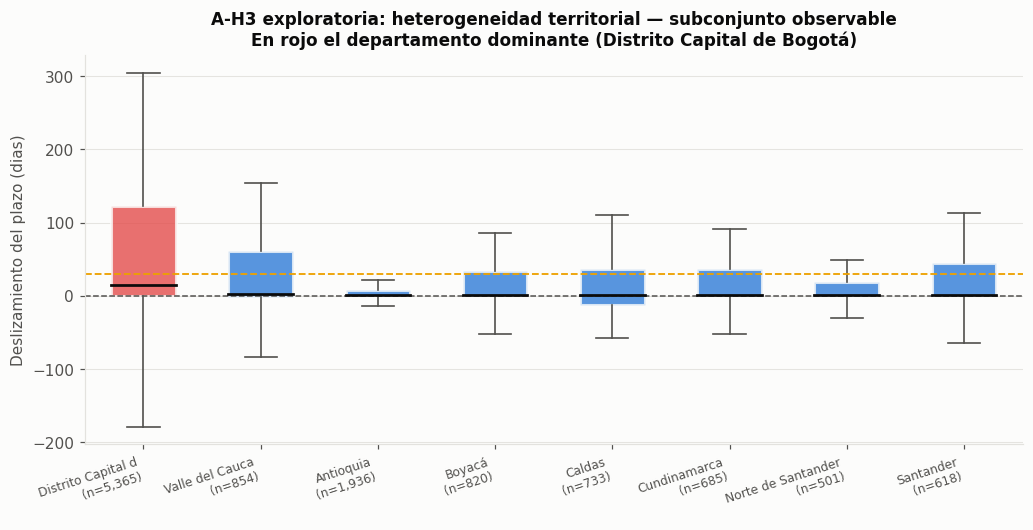

Figura persistida: 10_h3_territorial.png


In [12]:
marcar("fig_h3")

top8 = obs["departamento"].value_counts().head(8).index.tolist()
d8 = obs[obs["departamento"].isin(top8)]
orden = (d8.groupby("departamento")["deslizamiento_plazo_dias"].median()
         .sort_values(ascending=False).index.tolist())
datos = [d8.loc[d8["departamento"] == dd, "deslizamiento_plazo_dias"].dropna().clip(-200, 600)
         for dd in orden]
ns = [len(x) for x in datos]

fig, ax = plt.subplots(figsize=(11, 4.6))
bp = ax.boxplot(datos, patch_artist=True, showfliers=False, widths=0.55,
                medianprops=dict(color=TEXT_1, lw=1.8),
                whiskerprops=dict(color=TEXT_2, lw=1.1), capprops=dict(color=TEXT_2, lw=1.1))
for patch, dd in zip(bp["boxes"], orden):
    patch.set_facecolor(PALETA[7] if dd == DEP_DOMINANTE else PALETA[0])
    patch.set_alpha(0.78); patch.set_edgecolor(SURFACE); patch.set_linewidth(2)
ax.axhline(0, color=TEXT_2, lw=1, ls="--")
ax.axhline(30, color=PALETA[3], lw=1.2, ls="--")
ax.set_xticklabels([f"{dd[:18]}\n(n={n:,})" for dd, n in zip(orden, ns)],
                   fontsize=8, rotation=18, ha="right")
ax.set_ylabel("Deslizamiento del plazo (dias)")
ax.set_title(f"A-H3 exploratoria: heterogeneidad territorial — subconjunto observable\n"
             f"En rojo el departamento dominante ({DEP_DOMINANTE})", fontsize=11)
ax.xaxis.grid(False); ax.set_axisbelow(True)
guardar_mostrar(fig, "10_h3_territorial.png")

## 5. Cuadro consolidado de veredictos

In [13]:
marcar("veredictos")

veredictos = pd.DataFrame([
    {"hipotesis": "A-H1", "dimension": "Tiempo (deslizamiento del plazo)",
     "resultado": "SE INVIERTE",
     "evidencia": f"rank-biserial {bruto:+.3f} en el observable: la licitacion publica se retrasa MAS",
     "matiz": "El efecto se reduce al controlar por cuantia y la competencia real tiene efecto nulo"},
    {"hipotesis": "A-H1", "dimension": "Costo (desviacion de costo)",
     "resultado": "SE SOSTIENE",
     "evidencia": h1_base[(h1_base['lectura']=='observable') & (h1_base['indicador']=='Desviacion de costo (%)')]['rank_biserial'].iloc[0],
     "matiz": "Efecto mediano; la competencia real tambien discrimina en costo con efecto pequeno"},
    {"hipotesis": "A-H1", "dimension": "Costo (sobrecosto sobre precio base)",
     "resultado": "ver tabla h1_base",
     "evidencia": h1_base[(h1_base['lectura']=='observable') & (h1_base['indicador']=='Sobrecosto sobre el precio base (%)')]['rank_biserial'].iloc[0],
     "matiz": "Indicador nuevo, no disponible en el EDA previo"},
    {"hipotesis": "A-H2", "dimension": "Modificaciones totales",
     "resultado": "SE SOSTIENE",
     "evidencia": f"rank-biserial {bruto_h2:+.3f} en el observable, efecto mediano",
     "matiz": f"Se reduce {(1 - e2['rank_biserial'].abs().mean()/abs(bruto_h2))*100:.0f}% al controlar por cuantia"},
    {"hipotesis": "A-H2", "dimension": "Adiciones en valor",
     "resultado": "NO SE SOSTIENE",
     "evidencia": h2[(h2['lectura']=='observable') & (h2['variable']=='Adiciones en valor')]['rank_biserial'].iloc[0],
     "matiz": "Significancia estadistica con tamano de efecto nulo y medianas identicas"},
    {"hipotesis": "A-H2", "dimension": "Alcance (no entrega)",
     "resultado": "SE INVIERTE",
     "evidencia": "Los consorcios presentan MENOR tasa de no entrega que las personas juridicas",
     "matiz": "Patron mixto: mas modificaciones, mejor alcance"},
    {"hipotesis": "A-H3", "dimension": "Territorial",
     "resultado": "NO SE PRUEBA",
     "evidencia": "No existe NBI municipal en el dataset; el departamento no es NBI",
     "matiz": "La heterogeneidad en tiempo se desvanece al excluir el departamento dominante; en costo se refuerza"},
])
veredictos.to_csv(DIR_DATA / "veredictos_hipotesis.csv", index=False)
h1_base.to_csv(DIR_DATA / "h1_contraste_base.csv", index=False)
h2.to_csv(DIR_DATA / "h2_contraste_base.csv", index=False)
veredictos

,hipotesis,dimension,resultado,evidencia,matiz
0,A-H1,Tiempo (deslizamiento del plazo),SE INVIERTE,rank-biserial -0.380 en el observable: la lici...,El efecto se reduce al controlar por cuantia y...
1,A-H1,Costo (desviacion de costo),SE SOSTIENE,0.4079,Efecto mediano; la competencia real tambien di...
2,A-H1,Costo (sobrecosto sobre precio base),ver tabla h1_base,0.1341,"Indicador nuevo, no disponible en el EDA previo"
3,A-H2,Modificaciones totales,SE SOSTIENE,"rank-biserial -0.372 en el observable, efecto ...",Se reduce 74% al controlar por cuantia
4,A-H2,Adiciones en valor,NO SE SOSTIENE,-0.0173,Significancia estadistica con tamano de efecto...
5,A-H2,Alcance (no entrega),SE INVIERTE,Los consorcios presentan MENOR tasa de no entr...,"Patron mixto: mas modificaciones, mejor alcance"
6,A-H3,Territorial,NO SE PRUEBA,No existe NBI municipal en el dataset; el depa...,La heterogeneidad en tiempo se desvanece al ex...


## 6. Sintesis de hallazgos etiquetados

In [14]:
reg = RegistroHallazgos("10")
reg.add("H10-01",
        "A-H1 se invierte en tiempo y se sostiene en costo, en el universo completo (lectura oficial) y de forma consistente en el subconjunto observable, con el indicador de sobrecosto redefinido",
        f"Universo completo (lectura oficial), deslizamiento: rank-biserial {bruto_uc:+.4f}; observable (sensibilidad): {bruto_obs:+.4f}; costo: positivo con efecto mediano en ambas lecturas",
        ref("h1_base"), ["A-H1", "B-OE2"], "Alto",
        "Replica y extiende N-K01 al universo completo y al indicador de sobrecosto sobre precio base")
reg.add("H10-02",
        "El efecto de la modalidad sobre el deslizamiento del plazo se reduce sustancialmente al estratificar por cuantia",
        f"efecto bruto {abs(bruto):.4f} frente a magnitud media dentro de estratos {est['rank_biserial'].abs().mean():.4f}",
        ref("h1_veredicto"), ["A-H1", "A-OE03", "B-OE2"], "Alto",
        "Confirma la confusion modalidad-escala anticipada por el documento comparativo; control por estratificacion, no por regresion")
reg.add("H10-03",
        "A-H2 se sostiene en modificaciones totales, NO se sostiene en adiciones de valor pese al p-valor significativo, y se invierte en alcance",
        "Tabla de contraste de A-H2 en doble lectura, con tamano de efecto por variable",
        ref("h2_base"), ["A-H2", "B-OE2"], "Alto",
        "Rechazo explicito de un resultado significativo por tamano de efecto nulo")
reg.add("H10-04",
        "El efecto de A-H2 tambien se reduce al controlar por cuantia, aunque menos que el de A-H1",
        f"reduccion del {(1 - e2['rank_biserial'].abs().mean()/abs(bruto_h2))*100:.1f}% al estratificar",
        ref("h2_estratificado"), ["A-H2", "A-OE03"], "Alto",
        "Los consorcios se concentran en contratos de mayor cuantia, que acumulan mas modificaciones")
reg.add("H10-05",
        "CONTRADICE AL EDA PREVIO: la heterogeneidad territorial en TIEMPO se desvanece al excluir el departamento dominante; en COSTO se refuerza",
        f"epsilon2 en tiempo (observable) pasa de {h3[(h3.lectura=='observable')&(h3.indicador=='Deslizamiento del plazo')&(h3.escenario.str.startswith('CON'))].epsilon2.iloc[0]:.4f} a {h3[(h3.lectura=='observable')&(h3.indicador=='Deslizamiento del plazo')&(h3.escenario.str.startswith('SIN'))].epsilon2.iloc[0]:.4f}; en costo de {h3[(h3.lectura=='observable')&(h3.indicador=='Desviacion de costo')&(h3.escenario.str.startswith('CON'))].epsilon2.iloc[0]:.4f} a {h3[(h3.lectura=='observable')&(h3.indicador=='Desviacion de costo')&(h3.escenario.str.startswith('SIN'))].epsilon2.iloc[0]:.4f}",
        ref("h3_sensibilidad"), ["A-H3", "B-OE2", "CALIDAD"], "Alto",
        "Analisis de sensibilidad ausente en el EDA previo. El resultado territorial en tiempo del EDA previo es artefacto de un solo departamento y no debe presentarse como heterogeneidad general")
reg.add("H10-08",
        "`n_extension` del pipeline compartido es una bandera binaria, no un conteo: no puede sostener una prueba de 'mayor indice de extensiones'",
        "2 valores distintos (0 y 1) en las 48.331 filas; la prueba de A-H2 sobre esa variable devuelve p = 1.0 y efecto exactamente 0",
        ref("h2_base"), ["CALIDAD"], "Medio",
        "Impide usarla como magnitud; para el volumen de prorrogas debe usarse `dias_adicionados`")
reg.add("H10-06",
        "El peso del departamento dominante aumenta tras el filtro de observabilidad",
        "Comparacion de la participacion del departamento dominante entre universo y observable",
        ref("h3_territorio"), ["CALIDAD", "A-OE03"], "Alto",
        "Extension del insight N-06; debe declararse como limitacion junto al resultado territorial")
reg.add("H10-07",
        "El perfil de proveedor del registro externo no puede usarse para caracterizar A-H2 sin sesgo, porque su cobertura difiere fuertemente entre consorcios y personas juridicas",
        "Columna cobertura_registro_pct del perfil comparado", ref("h2_perfil"),
        ["CALIDAD", "A-H2"], "Alto",
        "Limitacion detectada y declarada antes de usar la variable, no despues")
reg.guardar()
reg.tabla()

,id,notebook,celda,hallazgo,evidencia,etiquetas,valor,nota
0,H10-01,10,c004,A-H1 se invierte en tiempo y se sostiene en co...,"Universo completo (lectura oficial), deslizami...",[A-H1] [B-OE2],Alto,Replica y extiende N-K01 al universo completo ...
1,H10-02,10,c006,El efecto de la modalidad sobre el deslizamien...,efecto bruto 0.3798 frente a magnitud media de...,[A-H1] [A-OE03] [B-OE2],Alto,Confirma la confusion modalidad-escala anticip...
2,H10-03,10,c008,"A-H2 se sostiene en modificaciones totales, NO...","Tabla de contraste de A-H2 en doble lectura, c...",[A-H2] [B-OE2],Alto,Rechazo explicito de un resultado significativ...
3,H10-04,10,c009,El efecto de A-H2 tambien se reduce al control...,reduccion del 73.6% al estratificar,[A-H2] [A-OE03],Alto,Los consorcios se concentran en contratos de m...
4,H10-05,10,c012,CONTRADICE AL EDA PREVIO: la heterogeneidad te...,epsilon2 en tiempo (observable) pasa de 0.0577...,[A-H3] [B-OE2] [CALIDAD],Alto,Analisis de sensibilidad ausente en el EDA pre...
5,H10-08,10,c008,`n_extension` del pipeline compartido es una b...,2 valores distintos (0 y 1) en las 48.331 fila...,[CALIDAD],Medio,Impide usarla como magnitud; para el volumen d...
6,H10-06,10,c011,El peso del departamento dominante aumenta tra...,Comparacion de la participacion del departamen...,[CALIDAD] [A-OE03],Alto,Extension del insight N-06; debe declararse co...
7,H10-07,10,c010,El perfil de proveedor del registro externo no...,Columna cobertura_registro_pct del perfil comp...,[CALIDAD] [A-H2],Alto,Limitacion detectada y declarada antes de usar...


## Sintesis del notebook 10

| ID | Hallazgo | Etiquetas |
|---|---|---|
| H10-01 | A-H1 se invierte en tiempo y se sostiene en costo, en el universo completo (lectura oficial, 48.331) y de forma consistente en el subconjunto observable (19.194) | `[A-H1]` `[B-OE2]` |
| H10-02 | El efecto de la modalidad sobre el plazo se reduce al estratificar por cuantia | `[A-H1]` `[A-OE03]` `[B-OE2]` |
| H10-03 | A-H2 se sostiene en modificaciones, no en adiciones de valor, y se invierte en alcance | `[A-H2]` `[B-OE2]` |
| H10-04 | El efecto de A-H2 tambien se reduce al controlar por cuantia | `[A-H2]` `[A-OE03]` |
| H10-05 | **Contradice al EDA previo**: la heterogeneidad territorial en tiempo se desvanece sin el departamento dominante; en costo se refuerza | `[A-H3]` `[B-OE2]` `[CALIDAD]` |
| H10-06 | El peso del departamento dominante aumenta tras el filtro de observabilidad | `[CALIDAD]` `[A-OE03]` |
| H10-07 | El perfil del registro externo no puede caracterizar A-H2 sin sesgo de cobertura | `[CALIDAD]` `[A-H2]` |
| H10-08 | `n_extension` es una bandera binaria, no un conteo | `[CALIDAD]` |

**Productos persistidos:** `data/h1_contraste_base.csv`, `data/h1_estratificado_por_cuantia.csv`,
`data/h2_contraste_base.csv`, `data/h2_estratificado_por_cuantia.csv`,
`data/h3_perfil_territorial.csv`, `data/h3_sensibilidad_territorial.csv`,
`data/veredictos_hipotesis.csv`, `figuras/10_h1_estratificado.png`, `figuras/10_h3_territorial.png`.

**Lo que un jurado cuestionara y como responderlo.**

| Cuestionamiento | Respuesta preparada |
|---|---|
| "¿Su hipotesis H1 se cumple o no?" | Se cumple en costo y se invierte en tiempo. Esa disociacion es el hallazgo, no un fracaso. Ademas se identifico que el mecanismo enunciado (la competencia) no es el que opera: medida con el numero real de oferentes, la competencia tiene efecto nulo sobre el plazo. |
| "¿Por que estratificacion y no regresion?" | Porque el alcance del trabajo es descriptivo-analitico. La estratificacion responde la misma pregunta de confusion sin asumir forma funcional ni requerir supuestos de residuos, y el efecto dentro de cada estrato es directamente interpretable. |
| "Diez pruebas sin correccion por comparaciones multiples" | Las hipotesis estaban preregistradas en el numeral 3.2 del anteproyecto, no son exploracion masiva. Los p-valores relevantes estan en ordenes muy inferiores a cualquier correccion concebible. La unica prueba en zona de riesgo ya fue descartada por tamano de efecto nulo. |
| "¿H3 esta probada?" | No, y se declara antes del resultado, no despues. El departamento no es NBI. El analisis de sensibilidad ademas muestra que la heterogeneidad territorial en tiempo depende casi por completo del departamento dominante, mientras que en costo es robusta. Presentar ambas cosas es mas defendible que presentar solo el estadistico global. Incorporar NBI del DANE es trabajo futuro inmediato. |